# 09 LoL-Aware Feature Reduction

Notebook นี้เปลี่ยนจาก dimensional reduction แบบทั่วไป เช่น PCA/SVD/t-SNE มาเป็นการลด feature แบบใช้ความเข้าใจเกม **League of Legends** โดยตรง

แนวคิดหลัก: แทนที่จะให้ PCA สร้างแกนที่อธิบาย variance ของข้อมูล เราสร้าง feature compact set จาก signal ที่คนเล่น LoL ใช้อ่านเกมจริง เช่น economy, farming, combat, objective control, lane matchup และการ convert lead เป็น objective

เป้าหมายคือดูว่าเราสามารถลดจาก all-features `959` features เหลือ feature ที่ตีความได้มากขึ้น แล้ว performance ยังใกล้ full model หรือไม่

In [11]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from catboost import CatBoostClassifier

RANDOM_STATE = 1337
DATA_PATH = Path('data/t2_transformed/merged_v1.csv')
OUTPUT_DIR = Path('outputs/lol_feature_reduction')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 180)

## 1. Load Raw Match Data

โหลดข้อมูล match-level เดิม แล้ว clean เฉพาะสิ่งที่จำเป็น:

- เอา `RedWin` ออกเพื่อกัน target leakage
- ใช้ `BlueWin` เป็น target
- แปลง lane `NONE` เป็น `JUNGLE`
- ยังไม่ทำ one-hot champion/spell/rune แบบ all-features เพราะ notebook นี้ต้องการ feature ที่ตีความด้วย LoL ได้ง่าย

In [12]:
raw_df = pd.read_csv(DATA_PATH)
raw_df = raw_df.drop(columns=[c for c in ['MatchFk', 'Patch'] if c in raw_df.columns], errors='ignore')
raw_df = raw_df[raw_df['BlueWin'] != raw_df['RedWin']].reset_index(drop=True)
raw_df = raw_df.drop(columns=['RedWin'], errors='ignore')
raw_df['BlueWin'] = raw_df['BlueWin'].astype(int)

for c in [f'Lane_P{p}' for p in range(1, 11)]:
    if c in raw_df.columns:
        raw_df[c] = raw_df[c].replace('NONE', 'JUNGLE')

load_summary = pd.DataFrame([
    {'item': 'rows', 'value': len(raw_df)},
    {'item': 'raw columns after cleaning', 'value': raw_df.shape[1]},
    {'item': 'blue win ratio', 'value': raw_df['BlueWin'].mean()},
])
display(load_summary)
load_summary.to_csv(OUTPUT_DIR / 'load_summary.csv', index=False)

,item,value
0,rows,91394.000000
1,raw columns after cleaning,142.000000
2,blue win ratio,0.500055


## 2. Build LoL Domain Feature Sets

สร้าง feature compact set จากหมวดที่มีความหมายในเกม:

- **Economy:** gold total/diff, gold distribution, max gold share
- **Farming:** CS total/diff
- **Combat:** kills/deaths/assists, KDA, damage dealt/taken
- **Efficiency:** damage per gold, turret damage per gold
- **Objectives:** dragon, Herald, tower, Baron, objective control index
- **Lead conversion:** gold/kill lead สอดคล้องกับ objective control หรือไม่
- **Lane matchup:** TOP/JUNGLE/MIDDLE/BOTTOM/SUPPORT diff ราย role

In [13]:
blue_players = [f'P{i}' for i in range(1, 6)]
red_players = [f'P{i}' for i in range(6, 11)]
roles = ['TOP', 'JUNGLE', 'MIDDLE', 'BOTTOM', 'SUPPORT']
base_stats = ['TotalGold', 'MinionsKilled', 'kills', 'deaths', 'assists', 'DmgDealt', 'DmgTaken', 'TurretDmgDealt']
objective_pairs = [
    ('BaronKills', 'BlueBaronKills', 'RedBaronKills'),
    ('RiftHeraldKills', 'BlueRiftHeraldKills', 'RedRiftHeraldKills'),
    ('DragonKills', 'BlueDragonKills', 'RedDragonKills'),
    ('TowerKills', 'BlueTowerKills', 'RedTowerKills'),
    ('TeamKills', 'BlueKills', 'RedKills'),
]

def safe_divide(num, den):
    out = num / den.replace(0, np.nan)
    return out.replace([np.inf, -np.inf], np.nan).fillna(0)

def build_lol_domain_features(df, include_lane_matchups=False):
    features = pd.DataFrame(index=df.index)

    # Team-level economy/combat/farming summaries.
    for stat in base_stats:
        blue_cols = [f'{stat}_{p}' for p in blue_players if f'{stat}_{p}' in df.columns]
        red_cols = [f'{stat}_{p}' for p in red_players if f'{stat}_{p}' in df.columns]
        if not blue_cols or not red_cols:
            continue
        features[f'Blue_{stat}_sum'] = df[blue_cols].sum(axis=1)
        features[f'Red_{stat}_sum'] = df[red_cols].sum(axis=1)
        features[f'Diff_{stat}'] = features[f'Blue_{stat}_sum'] - features[f'Red_{stat}_sum']
        features[f'Blue_{stat}_avg'] = df[blue_cols].mean(axis=1)
        features[f'Red_{stat}_avg'] = df[red_cols].mean(axis=1)

    # Fight efficiency.
    features['Blue_KDA'] = safe_divide(features['Blue_kills_sum'] + features['Blue_assists_sum'], features['Blue_deaths_sum'].replace(0, 1))
    features['Red_KDA'] = safe_divide(features['Red_kills_sum'] + features['Red_assists_sum'], features['Red_deaths_sum'].replace(0, 1))
    features['Diff_KDA'] = features['Blue_KDA'] - features['Red_KDA']
    features['Blue_Damage_per_Gold'] = safe_divide(features['Blue_DmgDealt_sum'], features['Blue_TotalGold_sum'])
    features['Red_Damage_per_Gold'] = safe_divide(features['Red_DmgDealt_sum'], features['Red_TotalGold_sum'])
    features['Diff_Damage_per_Gold'] = features['Blue_Damage_per_Gold'] - features['Red_Damage_per_Gold']
    features['Blue_TurretDamage_per_Gold'] = safe_divide(features['Blue_TurretDmgDealt_sum'], features['Blue_TotalGold_sum'])
    features['Red_TurretDamage_per_Gold'] = safe_divide(features['Red_TurretDmgDealt_sum'], features['Red_TotalGold_sum'])
    features['Diff_TurretDamage_per_Gold'] = features['Blue_TurretDamage_per_Gold'] - features['Red_TurretDamage_per_Gold']

    # Economy distribution: gold concentrated on one player vs spread across team.
    for side, players in [('Blue', blue_players), ('Red', red_players)]:
        gold_cols = [f'TotalGold_{p}' for p in players if f'TotalGold_{p}' in df.columns]
        if gold_cols:
            features[f'{side}_GoldStd'] = df[gold_cols].std(axis=1)
            features[f'{side}_MaxGoldShare'] = safe_divide(df[gold_cols].max(axis=1), df[gold_cols].sum(axis=1))
    features['Diff_GoldStd'] = features['Blue_GoldStd'] - features['Red_GoldStd']
    features['Diff_MaxGoldShare'] = features['Blue_MaxGoldShare'] - features['Red_MaxGoldShare']

    # Objective control and lead conversion.
    for name, blue_col, red_col in objective_pairs:
        if blue_col in df.columns and red_col in df.columns:
            features[blue_col] = df[blue_col]
            features[red_col] = df[red_col]
            features[f'Diff_{name}'] = df[blue_col] - df[red_col]

    objective_diff_cols = [c for c in ['Diff_DragonKills', 'Diff_RiftHeraldKills', 'Diff_TowerKills', 'Diff_BaronKills'] if c in features.columns]
    if objective_diff_cols:
        features['Objective_Control_Index'] = features[objective_diff_cols].sum(axis=1)

    if {'Diff_TotalGold', 'Diff_TeamKills', 'Objective_Control_Index'}.issubset(features.columns):
        features['Gold_Objective_Alignment'] = np.sign(features['Diff_TotalGold']) * np.sign(features['Objective_Control_Index'])
        features['Kill_Objective_Alignment'] = np.sign(features['Diff_TeamKills']) * np.sign(features['Objective_Control_Index'])

    # Compact directional signal count: how many major game signals favor each side.
    lead_cols = [c for c in ['Diff_TotalGold', 'Diff_MinionsKilled', 'Diff_kills', 'Diff_DmgDealt', 'Diff_KDA', 'Diff_DragonKills', 'Diff_TowerKills'] if c in features.columns]
    features['Blue_Lead_Signal_Count'] = (features[lead_cols] > 0).sum(axis=1)
    features['Red_Lead_Signal_Count'] = (features[lead_cols] < 0).sum(axis=1)
    features['Lead_Signal_Balance'] = features['Blue_Lead_Signal_Count'] - features['Red_Lead_Signal_Count']

    if include_lane_matchups:
        # Compare Blue vs Red by actual role/lane, compressing 10 player rows into lane matchup advantages.
        for role in roles:
            blue_role_mask = pd.DataFrame({p: df.get(f'Lane_{p}', pd.Series('', index=df.index)).eq(role) for p in blue_players})
            red_role_mask = pd.DataFrame({p: df.get(f'Lane_{p}', pd.Series('', index=df.index)).eq(role) for p in red_players})
            for stat in ['TotalGold', 'MinionsKilled', 'kills', 'deaths', 'assists', 'DmgDealt', 'DmgTaken']:
                blue_value = pd.Series(0.0, index=df.index)
                red_value = pd.Series(0.0, index=df.index)
                for p in blue_players:
                    col = f'{stat}_{p}'
                    if col in df.columns:
                        blue_value += df[col].where(blue_role_mask[p], 0)
                for p in red_players:
                    col = f'{stat}_{p}'
                    if col in df.columns:
                        red_value += df[col].where(red_role_mask[p], 0)
                features[f'{role}_{stat}_Diff'] = blue_value - red_value

    features = features.replace([np.inf, -np.inf], np.nan).fillna(0)
    return features

X_core = build_lol_domain_features(raw_df, include_lane_matchups=False)
X_lane = build_lol_domain_features(raw_df, include_lane_matchups=True)
y = raw_df['BlueWin']

feature_summary = pd.DataFrame([
    {'Feature_Set': 'LoL Core Signals', 'Feature_Count': X_core.shape[1]},
    {'Feature_Set': 'LoL Core + Lane Matchups', 'Feature_Count': X_lane.shape[1]},
    {'Feature_Set': 'Original All-Features', 'Feature_Count': 959},
])
display(feature_summary)
feature_summary.to_csv(OUTPUT_DIR / 'lol_feature_set_summary.csv', index=False)

,Feature_Set,Feature_Count
0,LoL Core Signals,76
1,LoL Core + Lane Matchups,111
2,Original All-Features,959


## 3. Evaluate Compact LoL Features

ทดสอบว่า feature ที่สร้างจากความเข้าใจเกมยังทำนายได้ดีแค่ไหน โดยใช้:

- `LogisticRegression`: อ่านง่าย เห็น coefficient ว่า signal ไหนดัน Blue/Red
- `CatBoost`: จับ interaction ระหว่าง LoL signals ได้ดีกว่า เช่น gold lead + objective control + lane pressure

In [14]:
def split_data(X, y):
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
    )
    return X_train, X_val, X_test, y_train, y_val, y_test

def evaluate_logistic(name, X, y):
    X_train, X_val, X_test, y_train, y_val, y_test = split_data(X, y)
    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc = scaler.transform(X_test)
    model = LogisticRegression(C=1.0, solver='lbfgs', penalty='l2', max_iter=500, random_state=42)
    model.fit(X_train_sc, y_train)
    prob = model.predict_proba(X_test_sc)[:, 1]
    pred = (prob >= 0.50).astype(int)
    coef = pd.DataFrame({
        'Feature_Set': name,
        'Model': 'LogisticRegression',
        'feature': X.columns,
        'coefficient': model.coef_[0],
    })
    coef['importance'] = coef['coefficient'].abs()
    coef['direction'] = np.where(coef['coefficient'] >= 0, 'Blue-favored', 'Red-favored')
    return {
        'Feature_Set': name,
        'Model': 'LogisticRegression',
        'Feature_Count': X.shape[1],
        'Test_AUC': roc_auc_score(y_test, prob),
        'Test_Accuracy': accuracy_score(y_test, pred),
        'Test_F1': f1_score(y_test, pred),
    }, coef.sort_values('importance', ascending=False)

def evaluate_catboost(name, X, y):
    X_train, X_val, X_test, y_train, y_val, y_test = split_data(X, y)
    model = CatBoostClassifier(
        iterations=500,
        depth=6,
        learning_rate=0.08,
        l2_leaf_reg=3.0,
        random_seed=42,
        verbose=0,
        early_stopping_rounds=50,
    )
    model.fit(X_train.values, y_train.values, eval_set=(X_val.values, y_val.values))
    prob = model.predict_proba(X_test.values)[:, 1]
    pred = (prob >= 0.50).astype(int)
    importance = pd.DataFrame({
        'Feature_Set': name,
        'Model': 'CatBoost_reduced_default',
        'feature': X.columns,
        'importance': model.feature_importances_,
    }).sort_values('importance', ascending=False)
    return {
        'Feature_Set': name,
        'Model': 'CatBoost_reduced_default',
        'Feature_Count': X.shape[1],
        'Test_AUC': roc_auc_score(y_test, prob),
        'Test_Accuracy': accuracy_score(y_test, pred),
        'Test_F1': f1_score(y_test, pred),
    }, importance

results = []
importance_tables = []
for feature_set_name, X_feat in [
    ('LoL Core Signals', X_core),
    ('LoL Core + Lane Matchups', X_lane),
]:
    print(f'Evaluating {feature_set_name}...')
    row, imp = evaluate_logistic(feature_set_name, X_feat, y)
    results.append(row)
    importance_tables.append(imp)

    row, imp = evaluate_catboost(feature_set_name, X_feat, y)
    results.append(row)
    importance_tables.append(imp)

lol_reduction_results = pd.DataFrame(results).sort_values('Test_AUC', ascending=False)
lol_feature_importance = pd.concat(importance_tables, ignore_index=True, sort=False)

lol_reduction_results.to_csv(OUTPUT_DIR / 'lol_reduction_performance.csv', index=False)
lol_feature_importance.to_csv(OUTPUT_DIR / 'lol_reduction_feature_importance.csv', index=False)

display(lol_reduction_results)

Evaluating LoL Core Signals...
Evaluating LoL Core + Lane Matchups...


,Feature_Set,Model,Feature_Count,Test_AUC,Test_Accuracy,Test_F1
3,LoL Core + Lane Matchups,CatBoost_reduced_default,111,0.783515,0.702699,0.699321
1,LoL Core Signals,CatBoost_reduced_default,76,0.782079,0.704230,0.701025
2,LoL Core + Lane Matchups,LogisticRegression,111,0.781834,0.702480,0.699919
0,LoL Core Signals,LogisticRegression,76,0.781246,0.703574,0.700869


## 4. Compare Against Full Models

เทียบ compact LoL features กับ full all-features models จาก notebook 08/05 เพื่อดู trade-off:

- ลด feature ได้เยอะไหม
- AUC ตกเท่าไร
- feature ยังตีความในภาษา LoL ได้หรือไม่

,Feature_Set,Model,Feature_Count,Test_AUC,Test_Accuracy,Test_F1
0,Full All-Features,CatBoost,959,0.799317,0.717724,0.714686
1,Full All-Features,LogisticRegression,959,0.797066,0.717433,0.715691
2,LoL Core + Lane Matchups,CatBoost_reduced_default,111,0.783515,0.702699,0.699321
3,LoL Core Signals,CatBoost_reduced_default,76,0.782079,0.704230,0.701025
4,LoL Core + Lane Matchups,LogisticRegression,111,0.781834,0.702480,0.699919
5,LoL Core Signals,LogisticRegression,76,0.781246,0.703574,0.700869


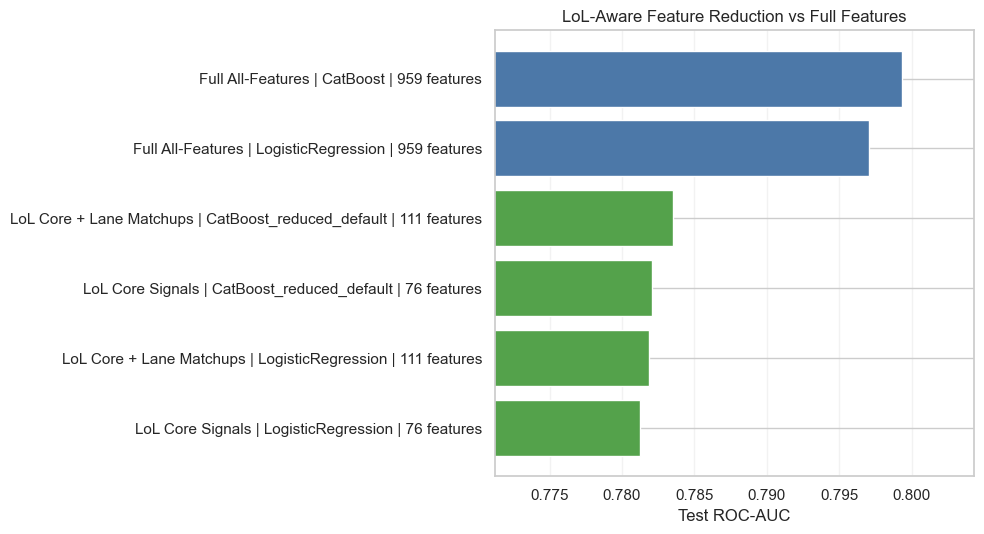

In [15]:
full_refs = []
roc_summary_path = Path('outputs/roc_auc_analysis/roc_auc_summary.csv')
if roc_summary_path.exists():
    roc_ref = pd.read_csv(roc_summary_path)
    for _, row in roc_ref.iterrows():
        if row['Model'] in ['CatBoost', 'LogisticRegression']:
            full_refs.append({
                'Feature_Set': 'Full All-Features',
                'Model': row['Model'],
                'Feature_Count': 959,
                'Test_AUC': row['ROC_AUC'],
                'Test_Accuracy': row['Accuracy_at_0_50'],
                'Test_F1': row['F1_at_0_50'],
            })

comparison = pd.concat([pd.DataFrame(full_refs), lol_reduction_results], ignore_index=True, sort=False)
comparison = comparison.sort_values('Test_AUC', ascending=False)
comparison.to_csv(OUTPUT_DIR / 'lol_reduction_vs_full_comparison.csv', index=False)
display(comparison)

plt.figure(figsize=(10, 5.5))
plot_data = comparison.sort_values('Test_AUC', ascending=True).copy()
plot_data['Label'] = plot_data['Feature_Set'] + ' | ' + plot_data['Model'] + ' | ' + plot_data['Feature_Count'].astype(int).astype(str) + ' features'
colors = np.where(plot_data['Feature_Set'].eq('Full All-Features'), '#4C78A8', '#54A24B')
plt.barh(plot_data['Label'], plot_data['Test_AUC'], color=colors)
plt.xlabel('Test ROC-AUC')
plt.title('LoL-Aware Feature Reduction vs Full Features')
plt.xlim(max(0.76, plot_data['Test_AUC'].min() - 0.01), min(0.81, plot_data['Test_AUC'].max() + 0.005))
plt.grid(axis='x', alpha=0.25)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'lol_reduction_vs_full_auc.png', dpi=160, bbox_inches='tight')
plt.show()

## 5. What LoL Signals Matter Most?

ดู feature importance ของ compact LoL features เพื่ออธิบายว่าตัวแทนที่ลดแล้วใช้ signal อะไรทำนายผล

,Feature_Set,Model,feature,importance
0,LoL Core + Lane Matchups,CatBoost_reduced_default,Diff_TotalGold,14.489777
1,LoL Core + Lane Matchups,CatBoost_reduced_default,Blue_MinionsKilled_sum,11.937270
2,LoL Core + Lane Matchups,CatBoost_reduced_default,Red_MinionsKilled_avg,5.545434
3,LoL Core + Lane Matchups,CatBoost_reduced_default,Diff_MinionsKilled,3.956609
4,LoL Core + Lane Matchups,CatBoost_reduced_default,Blue_MinionsKilled_avg,3.577755
5,LoL Core + Lane Matchups,CatBoost_reduced_default,JUNGLE_deaths_Diff,3.276215
6,LoL Core + Lane Matchups,CatBoost_reduced_default,Lead_Signal_Balance,2.909602
7,LoL Core + Lane Matchups,CatBoost_reduced_default,Red_MinionsKilled_sum,2.348669
8,LoL Core + Lane Matchups,CatBoost_reduced_default,BOTTOM_TotalGold_Diff,2.204533
9,LoL Core + Lane Matchups,CatBoost_reduced_default,Red_Lead_Signal_Count,1.888589


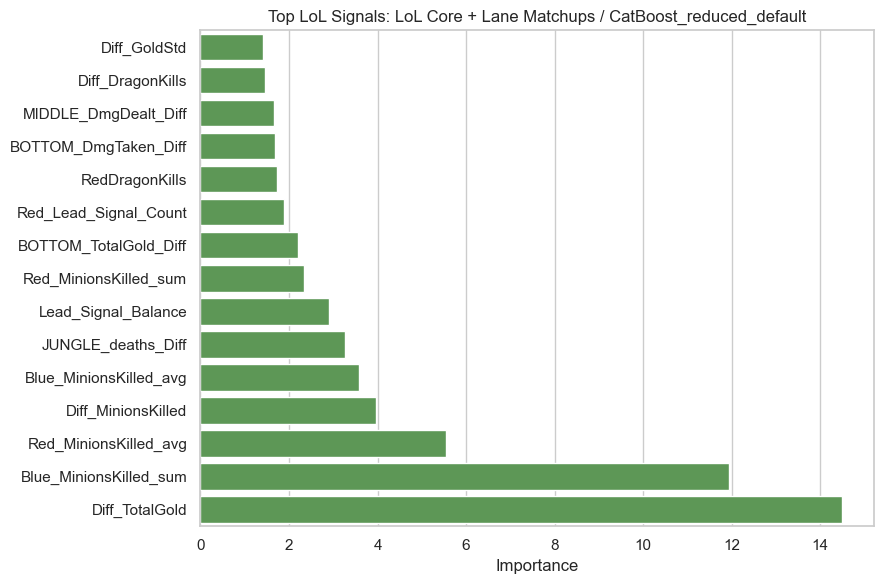

In [16]:
top_importance = (
    lol_feature_importance
    .sort_values(['Feature_Set', 'Model', 'importance'], ascending=[True, True, False])
    .groupby(['Feature_Set', 'Model'])
    .head(15)
    .reset_index(drop=True)
)
display(top_importance[['Feature_Set', 'Model', 'feature', 'importance']].head(60))
top_importance.to_csv(OUTPUT_DIR / 'lol_reduction_top_features.csv', index=False)

best_reduced_row = lol_reduction_results.iloc[0]
best_set = best_reduced_row['Feature_Set']
best_model = best_reduced_row['Model']
plot_imp = top_importance[(top_importance['Feature_Set'] == best_set) & (top_importance['Model'] == best_model)].sort_values('importance', ascending=True)

plt.figure(figsize=(9, 6))
sns.barplot(data=plot_imp, x='importance', y='feature', color='#54A24B')
plt.title(f'Top LoL Signals: {best_set} / {best_model}')
plt.xlabel('Importance')
plt.ylabel('')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'top_lol_signals_best_reduced_model.png', dpi=160, bbox_inches='tight')
plt.show()

## 6. Interpretation

การลดแบบ LoL-aware ไม่ได้พยายามชนะ full CatBoost แต่ต้องการ feature set ที่:

- เล็กกว่า all-features มาก
- อธิบายด้วยภาษาเกมได้
- ยัง performance ใกล้ baseline สำคัญพอสมควร

ถ้าต้องการ performance สูงสุด ใช้ full all-features หรือ top-k feature selection จาก CatBoost importance จะดีกว่า แต่ถ้าต้องการ insight สำหรับรายงาน LoL-aware feature set อ่านง่ายกว่า

In [17]:
best_reduced = lol_reduction_results.iloc[0]
full_cat = comparison[(comparison['Feature_Set'] == 'Full All-Features') & (comparison['Model'] == 'CatBoost')]
full_lr = comparison[(comparison['Feature_Set'] == 'Full All-Features') & (comparison['Model'] == 'LogisticRegression')]

lines = [
    f"Best LoL-aware reduced model: {best_reduced['Feature_Set']} with {best_reduced['Model']} ({int(best_reduced['Feature_Count'])} features), Test AUC={best_reduced['Test_AUC']:.4f}.",
]
if not full_cat.empty:
    lines.append(f"Gap vs full CatBoost: {best_reduced['Test_AUC'] - full_cat.iloc[0]['Test_AUC']:+.4f} AUC.")
if not full_lr.empty:
    lines.append(f"Gap vs full LogisticRegression: {best_reduced['Test_AUC'] - full_lr.iloc[0]['Test_AUC']:+.4f} AUC.")
lines.append('Conclusion: LoL-aware reduction keeps the model interpretable and compact, but performance drops compared with full all-features; this suggests champion/setup/raw high-dimensional signals still add predictive value.')

conclusion = '\n'.join(lines)
(OUTPUT_DIR / 'lol_feature_reduction_conclusion.txt').write_text(conclusion, encoding='utf-8')
print(conclusion)
print(f'Outputs saved to: {OUTPUT_DIR.resolve()}')

Best LoL-aware reduced model: LoL Core + Lane Matchups with CatBoost_reduced_default (111 features), Test AUC=0.7835.
Gap vs full CatBoost: -0.0158 AUC.
Gap vs full LogisticRegression: -0.0136 AUC.
Conclusion: LoL-aware reduction keeps the model interpretable and compact, but performance drops compared with full all-features; this suggests champion/setup/raw high-dimensional signals still add predictive value.
Outputs saved to: C:\Users\win25\Desktop\Desktop\work\CPE232 Data models\ProjectModelleing\Predicting-League-of-Legends-Match-Outcomes-Using-10-Minute-Data\outputs\lol_feature_reduction
